In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [84]:

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import one_hot

from sklearn.preprocessing import LabelEncoder
import pickle
import nltk
import re
from nltk.stem import PorterStemmer
from wordcloud import WordCloud 


In [85]:
df=pd.read_csv(r"C:\Users\user\Downloads\train.txt",sep=';',header=None,names=["comment","emotion"])

In [86]:
df.head()


,comment,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [87]:
df.shape

(16000, 2)

In [88]:
df.isnull().sum()

comment    0
emotion    0
dtype: int64

In [89]:
df.duplicated().sum()

np.int64(1)

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df1=df.copy()

EDA

In [92]:
df1['emotion'].value_counts()

emotion
joy         5361
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

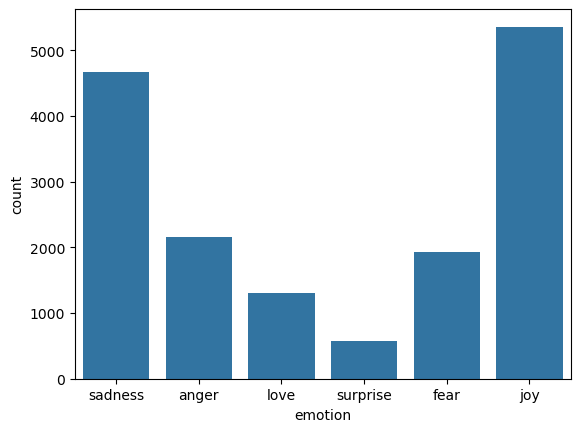

In [93]:
sns.countplot(x=df1['emotion'])

In [94]:
df1['length']=[len(x) for x in df1['comment']]

<Axes: xlabel='length', ylabel='Count'>

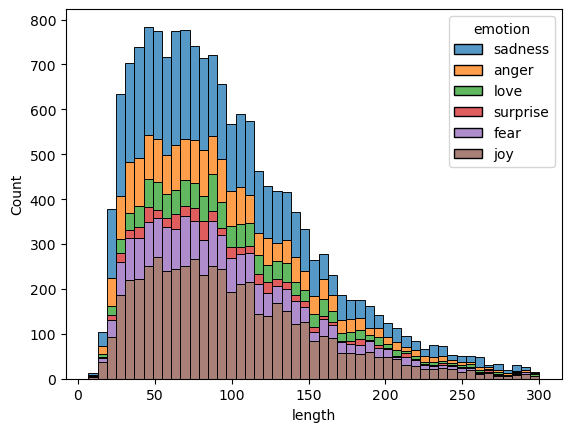

In [95]:
sns.histplot(data=df1,x='length',hue='emotion',multiple='stack')

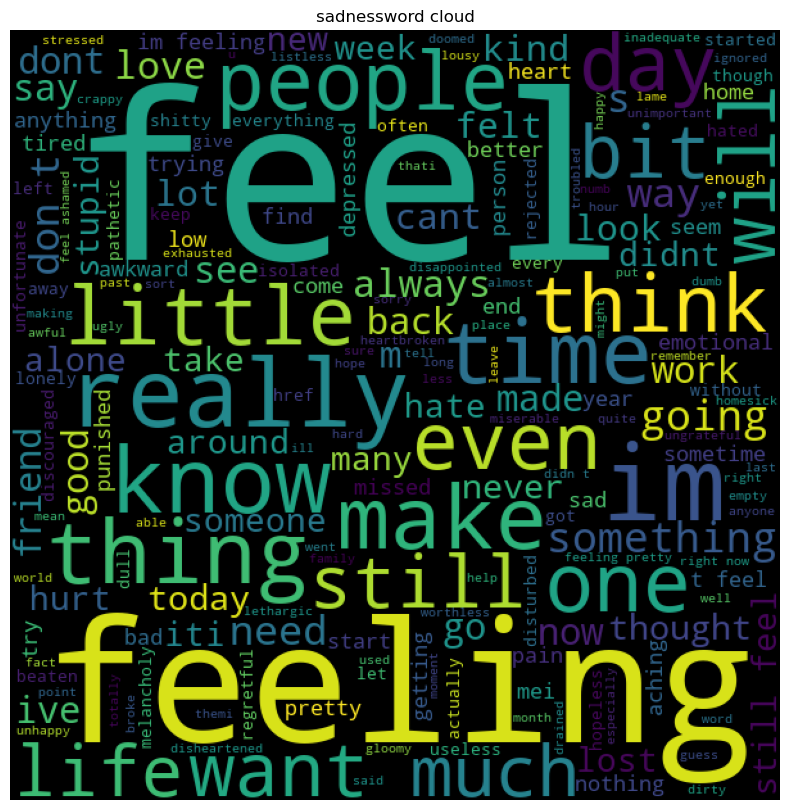

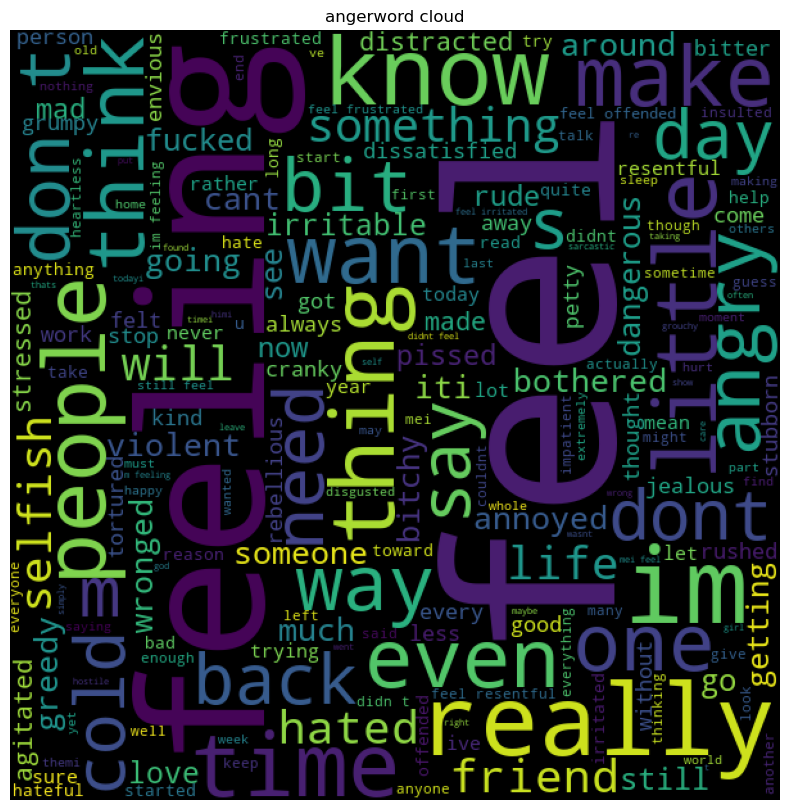

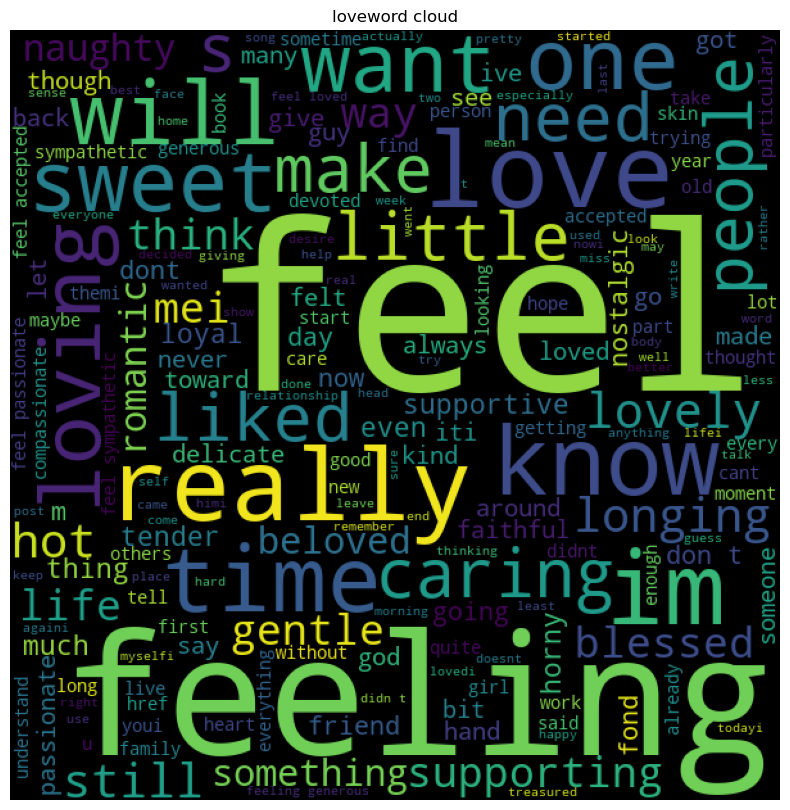

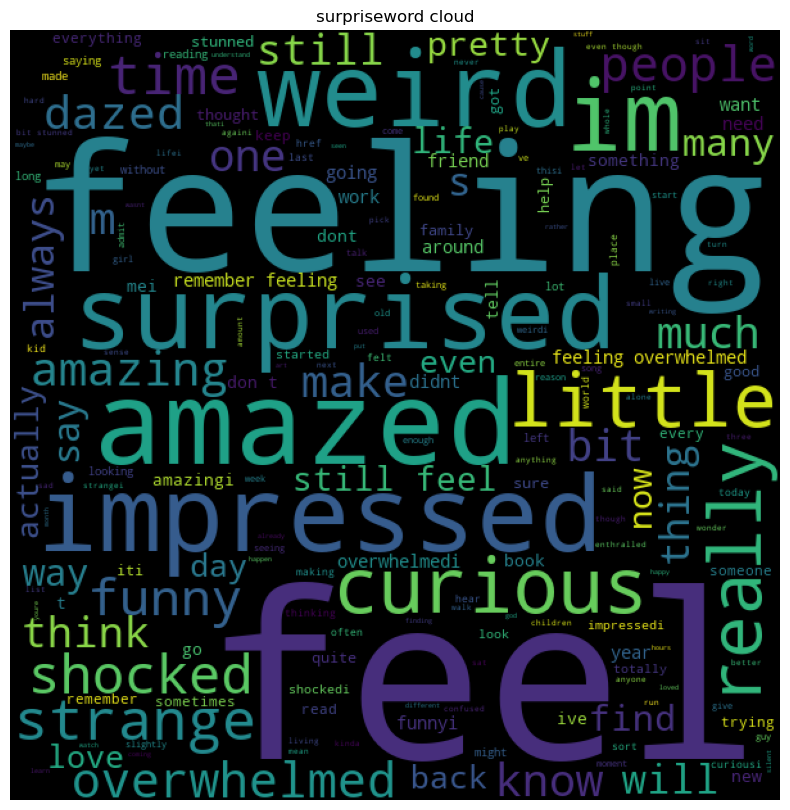

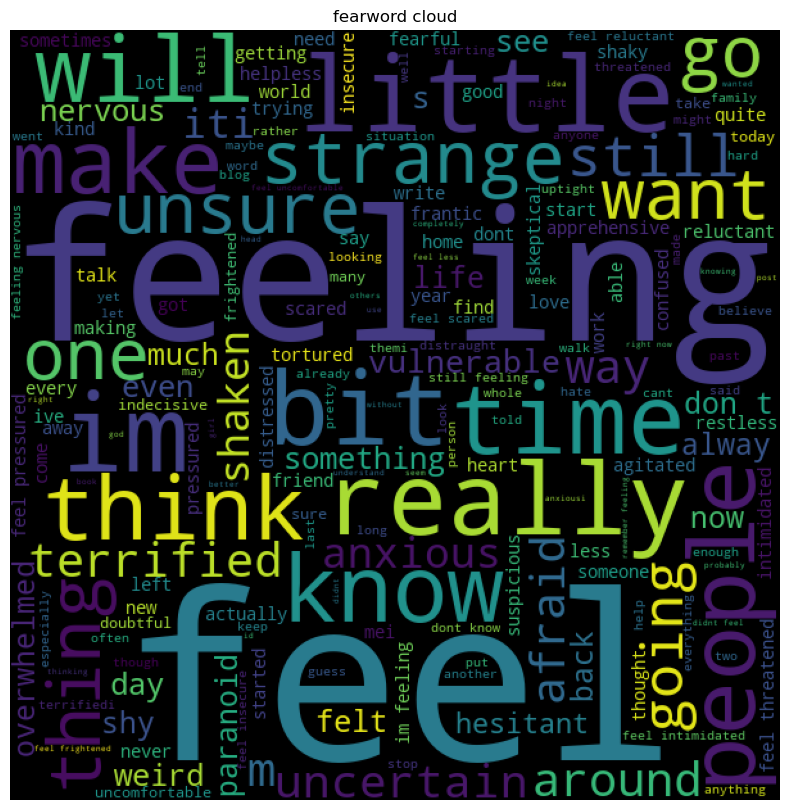

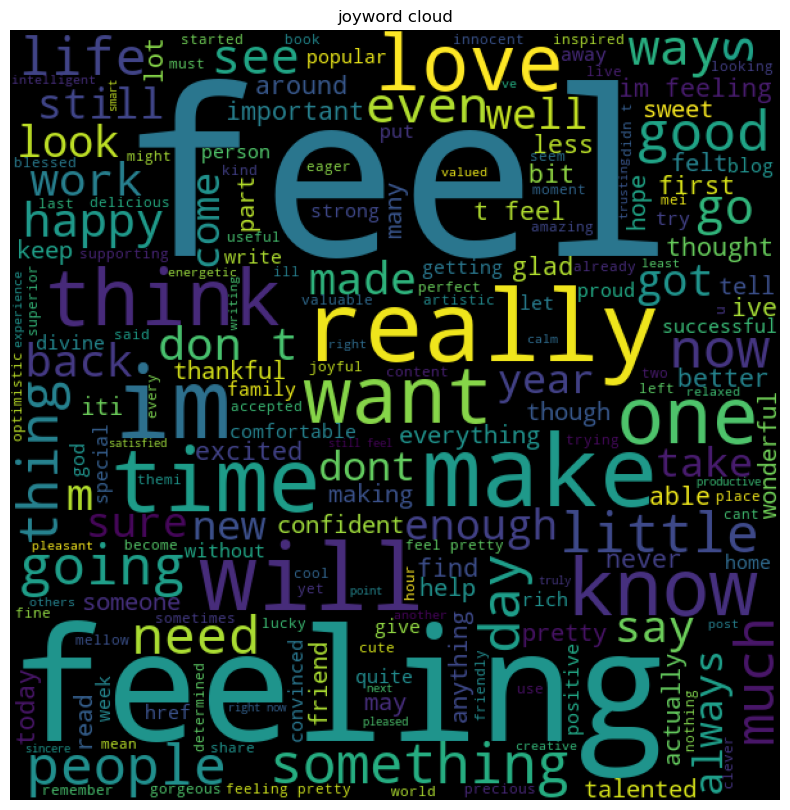

In [96]:
def word_cloud(wordcloud,emotions):
    plt.figure(figsize=(10,10))
    plt.title(emotions + 'word cloud')
    plt.imshow(wordcloud)
    plt.axis('off')
               
emotion_list =df1['emotion'].unique()
for emotions in emotion_list:
    text= ''.join([sentence for sentence in df1.loc[df1['emotion']==emotions,'comment']])
    wordcloud=WordCloud(width=600,height=600).generate(text)
    word_cloud(wordcloud,emotions)

In [97]:
label_encode=LabelEncoder()
df1['emotion']=label_encode.fit_transform(df1['emotion'])

In [98]:
df1.head()

,comment,emotion,length
0,i didnt feel humiliated,4,23
1,i can go from feeling so hopeless to so damned...,4,108
2,im grabbing a minute to post i feel greedy wrong,0,48
3,i am ever feeling nostalgic about the fireplac...,3,92
4,i am feeling grouchy,0,20


In [99]:
df2=df1.copy()

In [100]:
stopwords=(nltk.corpus.stopwords.words('english'))

In [101]:
def clean_text(text):
    stemmer=PorterStemmer()
    text=re.sub('[^a-zA-Z]',' ',text)
    text=text.lower()
    text=text.split()
    text=[stemmer.stem(word) for word in text if word not in stopwords]
    return ' '.join(text) 
df2['comment']=df2['comment'].apply(clean_text)

In [102]:
clean_text(' i am 12243 % loving, hating,loved ')  

'love hate love'

In [103]:
df2.head()

,comment,emotion,length
0,didnt feel humili,4,23
1,go feel hopeless damn hope around someon care ...,4,108
2,im grab minut post feel greedi wrong,0,48
3,ever feel nostalg fireplac know still properti,3,92
4,feel grouchi,0,20


In [104]:
from sklearn.model_selection import train_test_split

In [105]:
x_train,x_test,y_train,y_test=train_test_split(df2['comment'],df2['emotion'],test_size=0.2,random_state=42)

In [106]:
#vectorizing using tf_idf

In [107]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [108]:
tfid=TfidfVectorizer()
x_train_tfidf=tfid.fit_transform(x_train)
x_test_tfidf=tfid.transform(x_test)

In [109]:
classifier={ 'Multinomial Naive Bayes':MultinomialNB(),
             "Logistion Regression":LogisticRegression(),
             "Random Forest":RandomForestClassifier(),
             'Support vector machine':SVC()}
for name,clf in classifier.items():
    print(f'\n================{name}==========')
    clf.fit(x_train_tfidf,y_train)
    y_pred_tfidf=clf.predict(x_test_tfidf)
    print(f"\nAccuracy using TF IDF :{accuracy_score(y_test,y_pred_tfidf)}")
    print('classification report:')
    print(classification_report(y_test,y_pred_tfidf))


================Multinomial Naive Bayes==========

Accuracy using TF IDF :0.6590625
classification report:
              precision    recall  f1-score   support

           0       0.95      0.32      0.48       439
           1       0.88      0.23      0.37       375
           2       0.58      0.98      0.73      1027
           3       1.00      0.03      0.05       303
           4       0.72      0.91      0.80       950
           5       1.00      0.02      0.04       106

    accuracy                           0.66      3200
   macro avg       0.85      0.42      0.41      3200
weighted avg       0.76      0.66      0.59      3200


================Logistion Regression==========

Accuracy using TF IDF :0.825
classification report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       439
           1       0.85      0.72      0.78       375
           2       0.76      0.94      0.84      1027
           3       0.84      0.

In [110]:
lg=LogisticRegression()
lg.fit(x_train_tfidf,y_train)
y_pred_lg=lg.predict(x_test_tfidf)


In [111]:
def predict_emotion(input_text):
    cleaned_text= clean_text(input_text)
    input_vector=tfid.transform([cleaned_text])
    predicted_label=lg.predict(input_vector)[0]
    predicted_emotion=label_encode.inverse_transform([predicted_label])[0]
    label=predicted_label
    return predicted_emotion,label

In [112]:
#example
sentences='i went to trip i enjoyed a lot'
emo,label=predict_emotion(sentences)
print(emo)
print(label)

joy
2


In [113]:
#save files

In [114]:
pickle.dump(lg,open('logistic_regression.pkl','wb'))
pickle.dump(label_encode,open('label_encoder.pkl','wb'))
pickle.dump(tfid,open('tfidf_vectorizer.pkl','wb'))

Applying Deep learning using LSTM

In [115]:
df

,comment,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [116]:
df.head()

,comment,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [117]:
ps=PorterStemmer()
def process_title(comment):
    new_comment=comment.lower()
    new_comment=re.sub('[a^-zA-Z]',' ',new_comment)
    new_comment=re.sub(r'[^a-z0-9\s]','',new_comment)
    new_comment=re.sub(r'[0-9]+','number',new_comment) 
    new_comment=comment.split()
    new_comment=list(map(lambda x:ps.stem(x),new_comment))
    new_comment=list(map(lambda x:x.strip(),new_comment)) 
    if '' in new_comment:
        new_comment.remove('')
    return new_comment

In [118]:
le=LabelEncoder()
df['emotion']=le.fit_transform(df['emotion'])


In [119]:
df.head()

,comment,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


In [120]:
y_final=to_categorical(df['emotion'],num_classes=6)

In [121]:
y_final.shape

(15999, 6)

In [122]:
y_final

array([[0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]], shape=(15999, 6))

In [123]:
y_final=np.argmax(y_final,axis=1)

In [124]:
comments=df['comment'].apply(process_title)

In [125]:
comments

0                                 [i, didnt, feel, humili]
1        [i, can, go, from, feel, so, hopeless, to, so,...
2        [im, grab, a, minut, to, post, i, feel, greedi...
3        [i, am, ever, feel, nostalg, about, the, firep...
4                                   [i, am, feel, grouchi]
                               ...                        
15995    [i, just, had, a, veri, brief, time, in, the, ...
15996    [i, am, now, turn, and, i, feel, pathet, that,...
15997                 [i, feel, strong, and, good, overal]
15998    [i, feel, like, thi, wa, such, a, rude, commen...
15999    [i, know, a, lot, but, i, feel, so, stupid, be...
Name: comment, Length: 15999, dtype: object

In [126]:
vocab=set()
for comment in comments:
    for word in comment:
        if word not in vocab:
            vocab.add(word)
vocab_length=len(vocab)


max_seq_length=0
for comment in comments:
    if len(comment)>max_seq_length:
        max_seq_length=len(comment)

print("vocab_length:",vocab_length)
print("max_seq_length:",max_seq_length)

vocab_length: 10488
max_seq_length: 66


In [127]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer(num_words=vocab_length)
tokenizer.fit_on_texts(comments)

In [128]:
sequences=tokenizer.texts_to_sequences(comments)


In [129]:
sequences[0]

[1, 144, 2, 685]

In [130]:
model_inputs=pad_sequences(sequences,maxlen=max_seq_length,padding='post')

In [131]:
model_inputs

array([[   1,  144,    2, ...,    0,    0,    0],
       [   1,   40,   49, ...,    0,    0,    0],
       [  17, 1421,    6, ...,    0,    0,    0],
       ...,
       [   1,    2,  357, ...,    0,    0,    0],
       [   1,    2,   12, ...,    0,    0,    0],
       [   1,   42,    6, ...,    0,    0,    0]],
      shape=(15999, 66), dtype=int32)

In [132]:
model_inputs.shape

(15999, 66)

In [133]:
 X_train, X_test, y_train, y_test = train_test_split(model_inputs, y_final, test_size=0.33, random_state=42)

In [134]:
embedding_dim=64
input=tf.keras.Input(shape=(max_seq_length,))
embedding=tf.keras.layers.Embedding(input_dim=vocab_length,output_dim=embedding_dim,input_length=max_seq_length)(input)
gru=tf.keras.layers.GRU(units=embedding_dim,dropout=0.2,recurrent_dropout=0.2)(embedding)
outputs=tf.keras.layers.Dense(6,activation='softmax')(gru)
model=tf.keras.Model(input,outputs)
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [135]:
batch_size=32
epochs=10

In [136]:
history=model.fit(X_train,y_train,validation_split=0.2,batch_size=batch_size,epochs=epochs)

Epoch 1/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3354 - loss: 1.5877 - val_accuracy: 0.3251 - val_loss: 1.5899
Epoch 2/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3300 - loss: 1.5780 - val_accuracy: 0.3251 - val_loss: 1.5958
Epoch 3/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.3355 - loss: 1.5762 - val_accuracy: 0.3251 - val_loss: 1.5911
Epoch 4/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.3852 - loss: 1.5342 - val_accuracy: 0.5448 - val_loss: 1.2383
Epoch 5/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6393 - loss: 1.0087 - val_accuracy: 0.7519 - val_loss: 0.7718
Epoch 6/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7922 - loss: 0.6371 - val_accuracy: 0.8036 - val_loss: 0.5879
Epoch 7/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.8480 - loss: 0.4388 - val_accuracy: 0.8484 - val_loss: 0.4348
Epoch 8/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.8966 - loss: 0.3079 - 

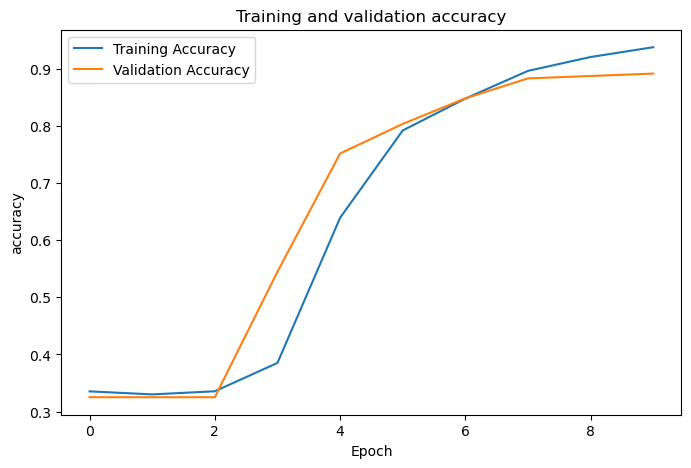

In [137]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

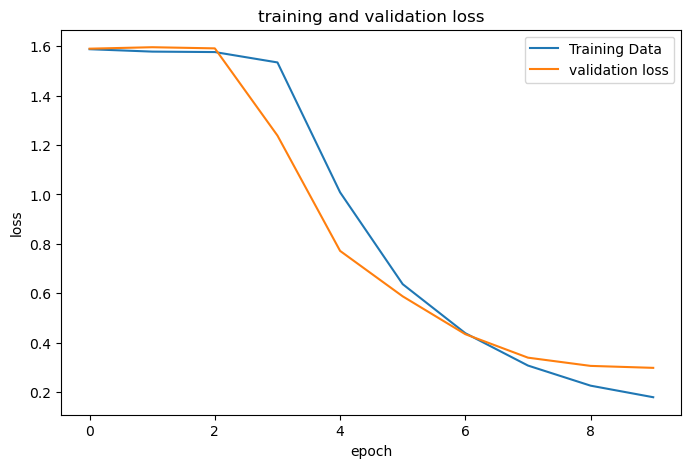

In [138]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Data')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title('training and validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show
    

In [139]:
accuarcy=model.evaluate(X_test,y_test)


165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9017 - loss: 0.2801


In [140]:
y_pred_probs=model.predict(X_test)

165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [141]:
y_pred=np.argmax(y_pred_probs,axis=1)

In [142]:
from sklearn.metrics import classification_report,confusion_matrix

In [143]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       687
           1       0.91      0.79      0.84       599
           2       0.94      0.92      0.93      1756
           3       0.76      0.77      0.76       484
           4       0.95      0.96      0.96      1575
           5       0.70      0.88      0.78       179

    accuracy                           0.90      5280
   macro avg       0.85      0.87      0.86      5280
weighted avg       0.90      0.90      0.90      5280



In [144]:
cm=confusion_matrix(y_test,y_pred)

In [145]:
cm

array([[ 636,   13,    7,    8,   23,    0],
       [  37,  473,    5,    4,   31,   49],
       [  24,    4, 1608,   95,   10,   15],
       [  14,    9,   74,  374,   11,    2],
       [  31,   13,    9,    9, 1513,    0],
       [   0,   10,    2,    5,    5,  157]])